In [84]:
# 세팅
!pip install --upgrade pandas xgboost
import pandas as pd
pd.plotting.register_matplotlib_converters()
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

In [85]:
# 파일 선택
test_path = '/kaggle/input/competitions/titanic/test.csv'
train_path = '/kaggle/input/competitions/titanic/train.csv'

train_data = pd.read_csv(train_path)
test = pd.read_csv(test_path)
train_data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [86]:
# 데이터 분할
from sklearn.model_selection import train_test_split

X = train_data.drop('Survived', axis=1)
y = train_data['Survived']

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=0)

print(f"학습 데이터 수: {len(X_train)}")
print(f"검증 데이터 수: {len(X_val)}")

학습 데이터 수: 712
검증 데이터 수: 179


Text(0, 0.5, 'Percentage')

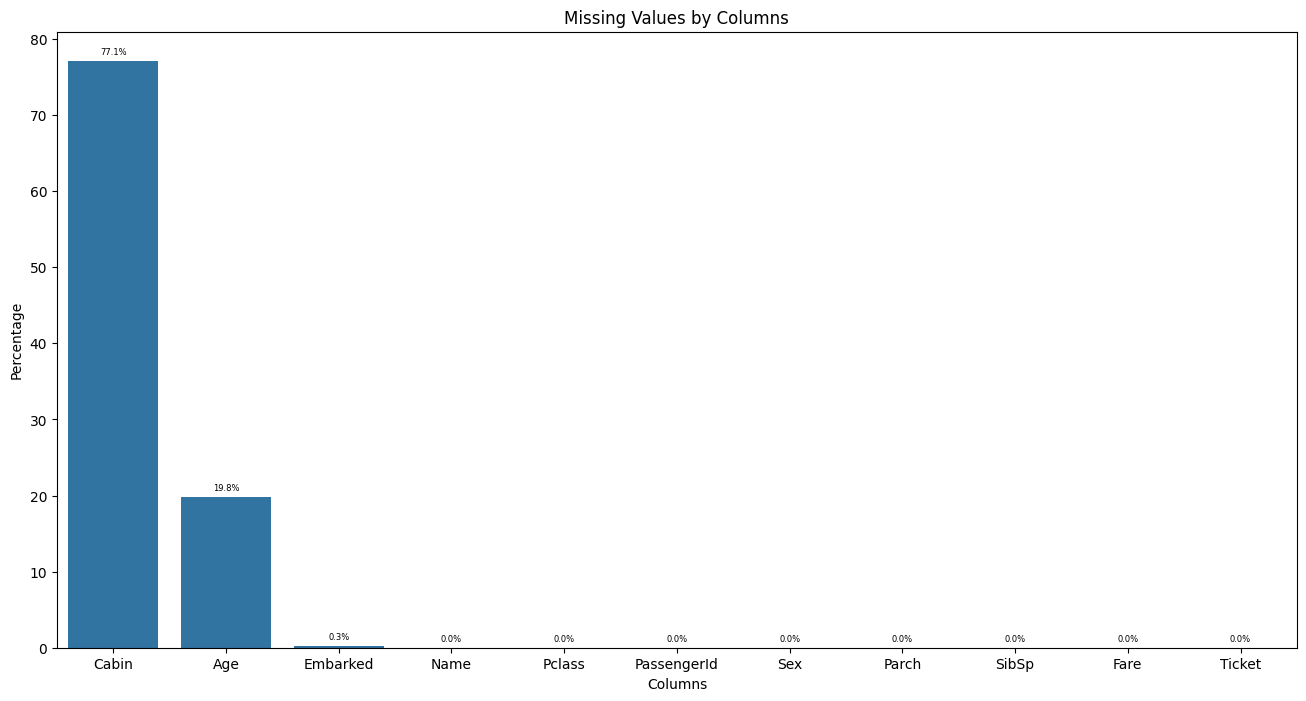

In [87]:
# 결측치 확인
null_percent = X_train.isnull().mean()*100

nulls = null_percent.sort_values(ascending=False)

plt.figure(figsize=(16,8))

ax = sns.barplot(x=nulls.index, y=nulls.values)

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', padding=3, fontsize=6)

plt.title("Missing Values by Columns")
plt.xlabel("Columns")
plt.ylabel("Percentage")

In [88]:
# Cabin은 결측치 매우 높으므로 삭제
# Age는 호칭별 중앙값으로 대치
# Embarked는 대치 또는 행 삭제 중 고려

In [89]:
# 상수 열 확인
n_unique = X_train.nunique()
constant_cols = n_unique[n_unique <= 1].index

print(f"상수열 개수: {len(constant_cols)}")
print(f"상수열 목록: {constant_cols.tolist()}")

상수열 개수: 0
상수열 목록: []


In [90]:
# Cabin열 삭제
train_dropped = X_train.drop(columns='Cabin')
valid_dropped = X_val.drop(columns='Cabin')
print(f"Cabin 삭제 후 학습 데이터 cloumns 수: {len(train_dropped.columns)}")
print(f"Cabin 삭제 후 검증 데이터 cloumns 수: {len(valid_dropped.columns)}")

# Age열 대체(Name의 호칭 별 중앙값으로 대체)
# 호칭(Title) 추출
train_dropped['Title'] = train_dropped['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)
valid_dropped['Title'] = valid_dropped['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)

# 호칭별 나이 중앙값 계산
title_age_map = train_dropped.groupby('Title')['Age'].median()

# Age 결측치 호칭별 중앙값으로 대체
train_dropped['Age'] = train_dropped['Age'].fillna(train_dropped['Title'].map(title_age_map))
valid_dropped['Age'] = valid_dropped['Age'].fillna(valid_dropped['Title'].map(title_age_map))

# 확인
print(train_dropped[['Name', 'Title', 'Age']].head(10))
print(valid_dropped[['Name', 'Title', 'Age']].head(10))

# Embarked 결측 행 삭제
print(f"학습 데이터 Embarked 결측행 수: {train_dropped.isnull().sum().sum()}")
print(f"검증 데이터 Embarked 결측행 수: {valid_dropped.isnull().sum().sum()}")
train_dropped2 = train_dropped.dropna(subset=['Embarked'])
valid_dropped2 = valid_dropped.dropna(subset=['Embarked'])
print(f"학습 데이터 Embarked 결측행 삭제 전 열 수: {len(train_dropped)}")
print(f"검증 데이터 Embarked 결측행 삭제 전 열 수: {len(valid_dropped)}")
print(f"학습 데이터 Embarked 결측행 삭제 후 열 수: {len(train_dropped2)}")
print(f"검증 데이터 Embarked 결측행 삭제 후 열 수: {len(valid_dropped2)}")

# 최종 점검
print(f"학습 데이터 최종 결측치 수: {train_dropped2.isnull().sum().sum()}")
print(f"검증 데이터 최종 결측치 수: {valid_dropped2.isnull().sum().sum()}")

Cabin 삭제 후 학습 데이터 cloumns 수: 10
Cabin 삭제 후 검증 데이터 cloumns 수: 10
                                       Name Title   Age
140           Boulos, Mrs. Joseph (Sultana)   Mrs  35.0
439  Kvillner, Mr. Johan Henrik Johannesson    Mr  31.0
817                      Mallet, Mr. Albert    Mr  31.0
378                     Betros, Mr. Tannous    Mr  20.0
491                     Windelov, Mr. Einar    Mr  21.0
331                     Partner, Mr. Austen    Mr  45.5
588                   Gilinski, Mr. Eliezer    Mr  22.0
358                    McGovern, Miss. Mary  Miss  21.0
674              Watson, Mr. Ennis Hastings    Mr  30.0
162              Bengtsson, Mr. John Viktor    Mr  26.0
                                               Name   Title   Age
495                           Yousseff, Mr. Gerious      Mr  30.0
648                              Willey, Mr. Edward      Mr  30.0
278                              Rice, Master. Eric  Master   7.0
31   Spencer, Mrs. William Augustus (Marie Eugenie)     

<>:9: SyntaxWarning: invalid escape sequence '\.'
<>:10: SyntaxWarning: invalid escape sequence '\.'
<>:9: SyntaxWarning: invalid escape sequence '\.'
<>:10: SyntaxWarning: invalid escape sequence '\.'
/tmp/ipykernel_55/3867665132.py:9: SyntaxWarning: invalid escape sequence '\.'
  train_dropped['Title'] = train_dropped['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)
/tmp/ipykernel_55/3867665132.py:10: SyntaxWarning: invalid escape sequence '\.'
  valid_dropped['Title'] = valid_dropped['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)


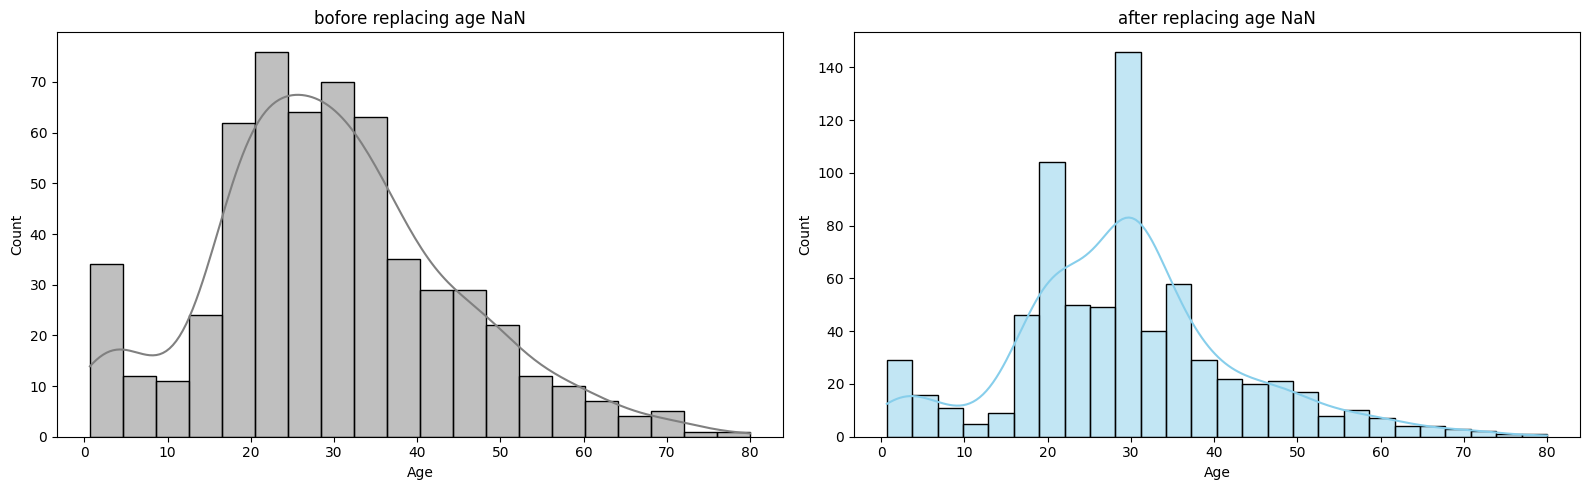

In [91]:
# 대체 후 분포 변화 확인
fig, axes = plt.subplots(1, 2, figsize=(16,5))

sns.histplot(X_train['Age'], kde=True, ax=axes[0], color='gray')
axes[0].set_title("bofore replacing age NaN")

sns.histplot(train_dropped['Age'], kde=True, ax=axes[1], color='skyblue')
axes[1].set_title("after replacing age NaN")

plt.tight_layout()
plt.show()

In [92]:
# 분포가 많이 변했지만, 자연스러운 현상이라 봄
# 호칭별 중앙값으로 대체했으니, 정교하게 잘 대체됐다 볼 수 있음

In [93]:
# 각 열의 데이터 타입 확인
print(train_dropped2.dtypes)
print("-" * 22)
print(train_dropped2.iloc[0])

PassengerId      int64
Pclass           int64
Name               str
Sex                str
Age            float64
SibSp            int64
Parch            int64
Ticket             str
Fare           float64
Embarked           str
Title              str
dtype: object
----------------------
PassengerId                              141
Pclass                                     3
Name           Boulos, Mrs. Joseph (Sultana)
Sex                                   female
Age                                     35.0
SibSp                                      0
Parch                                      2
Ticket                                  2678
Fare                                 15.2458
Embarked                                   C
Title                                    Mrs
Name: 140, dtype: object


In [94]:
# 문자 데이터 확인
categorical_cols1 = [col for col in train_dropped2.columns if train_dropped2[col].dtype.name in ["object","category","string","str"]]
print(categorical_cols1)
for i in categorical_cols1:
    print(f"{i}: {train_dropped2[i].nunique()}\n")
    print(f"{i}: {train_dropped2[i].value_counts()}\n")

categorical_cols2 = [col for col in valid_dropped2.columns if valid_dropped2[col].dtype.name in ["object","category","string","str"]]
print(categorical_cols2)
for i in categorical_cols2:
    print(f"{i}: {valid_dropped2[i].nunique()}\n")
    print(f"{i}: {valid_dropped2[i].value_counts()}\n")

['Name', 'Sex', 'Ticket', 'Embarked', 'Title']
Name: 710

Name: Name
Boulos, Mrs. Joseph (Sultana)                      1
Kvillner, Mr. Johan Henrik Johannesson             1
Mallet, Mr. Albert                                 1
Betros, Mr. Tannous                                1
Windelov, Mr. Einar                                1
                                                  ..
Compton, Miss. Sara Rebecca                        1
Andersen-Jensen, Miss. Carla Christine Nielsine    1
O'Connell, Mr. Patrick D                           1
de Messemaeker, Mrs. Guillaume Joseph (Emma)       1
Brown, Mr. Thomas William Solomon                  1
Name: count, Length: 710, dtype: int64

Sex: 2

Sex: Sex
male      465
female    245
Name: count, dtype: int64

Ticket: 568

Ticket: Ticket
CA. 2343    7
347082      6
CA 2144     5
1601        5
LINE        4
           ..
PC 17476    1
PC 17756    1
350046      1
334912      1
345572      1
Name: count, Length: 568, dtype: int64

Embarked: 3

E

In [95]:
# PassengerId, Name, Ticket: 이름은 이미 title로 뽑아냈고, 티켓번호와 ID는 양이 너무 많고, 생존 유무에 크게 의미 없다고 판단 -> 제거
# Sex, Embarked: 고유값이 매우 적고 명확 -> One-Hot Encoding
# Title: 15개의 고유값을 갖지만, 대부분이 Mr, Miss, Mrs, Master 4종류임. 나머지는 Other로 분류 -> One-Hot Encoding

In [96]:
# 가족 수 = 형제/배우자 + 부모/자녀 + 본인
train_dropped2['FamilySize'] = train_dropped2['SibSp'] + train_dropped2['Parch'] + 1
valid_dropped2['FamilySize'] = valid_dropped2['SibSp'] + valid_dropped2['Parch'] + 1

# 혼자 왔는지 여부
train_dropped2['IsAlone'] = 0
train_dropped2.loc[train_dropped2['FamilySize'] == 1, 'IsAlone'] = 1

valid_dropped2['IsAlone'] = 0
valid_dropped2.loc[valid_dropped2['FamilySize'] == 1, 'IsAlone'] = 1

# 2차 피처링: 어린 아이인지 확인
for df in [train_dropped2, valid_dropped2]:
    df['IsChild'] = (df['Age'] < 16).astype(int)

# 요금을 4개의 구간으로 나눔
train_dropped2['FareBin'] = pd.qcut(train_dropped2['Fare'], 4, labels=[0, 1, 2, 3]).astype(int)
valid_dropped2['FareBin'] = pd.qcut(valid_dropped2['Fare'], 4, labels=[0, 1, 2, 3]).astype(int)

# 나이와 객실 등급을 결합한 상호작용 피처
train_dropped2['Age_Class'] = train_dropped2['Age'] * train_dropped2['Pclass']
valid_dropped2['Age_Class'] = valid_dropped2['Age'] * valid_dropped2['Pclass']

print(train_dropped2.columns)
print(valid_dropped2.columns)

Index(['PassengerId', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch',
       'Ticket', 'Fare', 'Embarked', 'Title', 'FamilySize', 'IsAlone',
       'IsChild', 'FareBin', 'Age_Class'],
      dtype='str')
Index(['PassengerId', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch',
       'Ticket', 'Fare', 'Embarked', 'Title', 'FamilySize', 'IsAlone',
       'IsChild', 'FareBin', 'Age_Class'],
      dtype='str')


In [97]:
# Name, Ticket 삭제
cols_to_drop = ['PassengerId', 'Name', 'Ticket']
train_dropped3 = train_dropped2.drop(columns=cols_to_drop)
valid_dropped3 = valid_dropped2.drop(columns=cols_to_drop)

print(f"훈련 데이터 열: {train_dropped3.columns.tolist()}\n검증 데이터 열: {valid_dropped3.columns.tolist()}")

# Title 분류
target_title = ['Mr','Miss','Mrs','Master']

train_dropped3['Title'] = train_dropped3['Title'].apply(lambda x: x if x in target_title else 'others')
valid_dropped3['Title'] = valid_dropped3['Title'].apply(lambda x: x if x in target_title else 'others')

# Sex, Embarked, Title, IsChild 인코딩

from sklearn.preprocessing import OneHotEncoder

cols_to_encode = ['Sex','Embarked','Title','IsChild']

ohencoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

encoded_train = ohencoder.fit_transform(train_dropped3[cols_to_encode])
encoded_valid = ohencoder.transform(valid_dropped3[cols_to_encode])

encoded_columns_names = ohencoder.get_feature_names_out(cols_to_encode)

oh_cols_train = pd.DataFrame(encoded_train, columns=encoded_columns_names, index=train_dropped3.index)
oh_cols_valid = pd.DataFrame(encoded_valid, columns=encoded_columns_names, index=valid_dropped3.index)

num_X_train = train_dropped3.drop(cols_to_encode, axis=1)
num_X_valid = valid_dropped3.drop(cols_to_encode, axis=1)

oh_X_train = pd.concat([num_X_train, oh_cols_train], axis=1)
oh_X_valid = pd.concat([num_X_valid, oh_cols_valid], axis=1)

oh_X_train.columns = oh_X_train.columns.astype(str)
oh_X_valid.columns = oh_X_valid.columns.astype(str)

# 확인
train_object_cols = [col for col in oh_X_train.columns if oh_X_train[col].dtype == 'object']
valid_object_cols = [col for col in oh_X_valid.columns if oh_X_valid[col].dtype == 'object']
print(f"훈련 데이터 categorical values 수: {len(train_object_cols)}")
print(f"검증 데이터 categorical values 수: {len(valid_object_cols)}")

oh_X_train.head()

훈련 데이터 열: ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked', 'Title', 'FamilySize', 'IsAlone', 'IsChild', 'FareBin', 'Age_Class']
검증 데이터 열: ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked', 'Title', 'FamilySize', 'IsAlone', 'IsChild', 'FareBin', 'Age_Class']
훈련 데이터 categorical values 수: 0
검증 데이터 categorical values 수: 0


,Pclass,Age,SibSp,Parch,Fare,FamilySize,IsAlone,FareBin,Age_Class,Sex_female,...,Embarked_C,Embarked_Q,Embarked_S,Title_Master,Title_Miss,Title_Mr,Title_Mrs,Title_others,IsChild_0,IsChild_1
140,3,35.0,0,2,15.2458,3,0,2,105.0,1.0,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
439,2,31.0,0,0,10.5000,1,1,1,62.0,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
817,2,31.0,1,1,37.0042,3,0,3,62.0,0.0,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
378,3,20.0,0,0,4.0125,1,1,0,60.0,0.0,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
491,3,21.0,0,0,7.2500,1,1,0,63.0,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0


In [98]:
# 스케일링: 각각의 열들이 동일한 영향력을 갖게하기 위해 StandardScaler 사용
# randomforest 모델에는 스캐일링이 필수적이지 않지만, 성능 향상을 위해 다른 모델을 고려할 상황을 대비하여 실시

In [99]:
# 스캐일링
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaled_X_train = pd.DataFrame(scaler.fit_transform(oh_X_train), columns=oh_X_train.columns)
scaled_X_valid = pd.DataFrame(scaler.transform(oh_X_valid), columns=oh_X_valid.columns)

scaled_X_train.index = oh_X_train.index
scaled_X_valid.index = oh_X_valid.index

print("스케일링 완료")
scaled_X_train.head()

스케일링 완료


,Pclass,Age,SibSp,Parch,Fare,FamilySize,IsAlone,FareBin,Age_Class,Sex_female,...,Embarked_C,Embarked_Q,Embarked_S,Title_Master,Title_Miss,Title_Mr,Title_Mrs,Title_others,IsChild_0,IsChild_1
140,0.816532,0.428390,-0.465247,1.955795,-0.328938,0.646344,-1.231962,0.449735,1.235407,1.377664,...,2.122234,-0.314756,-1.636691,-0.22771,-0.504398,-1.199943,2.544344,-0.156624,0.330719,-0.330719
439,-0.386243,0.128469,-0.465247,-0.478236,-0.423655,-0.554976,0.811713,-0.444695,-0.061994,-0.725866,...,-0.471202,-0.314756,0.610989,-0.22771,-0.504398,0.833373,-0.393029,-0.156624,0.330719,-0.330719
817,-0.386243,0.128469,0.410948,0.738780,0.105315,0.646344,-1.231962,1.344165,-0.061994,-0.725866,...,2.122234,-0.314756,-1.636691,-0.22771,-0.504398,0.833373,-0.393029,-0.156624,0.330719,-0.330719
378,0.816532,-0.696312,-0.465247,-0.478236,-0.553132,-0.554976,0.811713,-1.339126,-0.122339,-0.725866,...,2.122234,-0.314756,-1.636691,-0.22771,-0.504398,0.833373,-0.393029,-0.156624,0.330719,-0.330719
491,0.816532,-0.621332,-0.465247,-0.478236,-0.488518,-0.554976,0.811713,-1.339126,-0.031822,-0.725866,...,-0.471202,-0.314756,0.610989,-0.22771,-0.504398,0.833373,-0.393029,-0.156624,0.330719,-0.330719


In [100]:
# y데이터 행 일치
y_train_final = y_train.loc[oh_X_train.index]
y_val_final = y_val.loc[oh_X_valid.index]

print("학습 데이터 shape:", scaled_X_train.shape, y_train_final.shape)
print("검증 데이터 shape:", scaled_X_valid.shape, y_val_final.shape)

학습 데이터 shape: (710, 21) (710,)
검증 데이터 shape: (179, 21) (179,)


In [101]:
# 2차 피처링
# FareBin, Embarked_Q 제거
drop_cols = ['FareBin','Embarked_Q']

X_train_final = scaled_X_train.drop(columns=drop_cols)
X_val_final = scaled_X_valid.drop(columns=drop_cols)

print(f"제거된 컬럼: {drop_cols}")
print(f"최종 피처 개수:{X_train_final.shape[1]}개")

X_train_final.head()

제거된 컬럼: ['FareBin', 'Embarked_Q']
최종 피처 개수:19개


,Pclass,Age,SibSp,Parch,Fare,FamilySize,IsAlone,Age_Class,Sex_female,Sex_male,Embarked_C,Embarked_S,Title_Master,Title_Miss,Title_Mr,Title_Mrs,Title_others,IsChild_0,IsChild_1
140,0.816532,0.428390,-0.465247,1.955795,-0.328938,0.646344,-1.231962,1.235407,1.377664,-1.377664,2.122234,-1.636691,-0.22771,-0.504398,-1.199943,2.544344,-0.156624,0.330719,-0.330719
439,-0.386243,0.128469,-0.465247,-0.478236,-0.423655,-0.554976,0.811713,-0.061994,-0.725866,0.725866,-0.471202,0.610989,-0.22771,-0.504398,0.833373,-0.393029,-0.156624,0.330719,-0.330719
817,-0.386243,0.128469,0.410948,0.738780,0.105315,0.646344,-1.231962,-0.061994,-0.725866,0.725866,2.122234,-1.636691,-0.22771,-0.504398,0.833373,-0.393029,-0.156624,0.330719,-0.330719
378,0.816532,-0.696312,-0.465247,-0.478236,-0.553132,-0.554976,0.811713,-0.122339,-0.725866,0.725866,2.122234,-1.636691,-0.22771,-0.504398,0.833373,-0.393029,-0.156624,0.330719,-0.330719
491,0.816532,-0.621332,-0.465247,-0.478236,-0.488518,-0.554976,0.811713,-0.031822,-0.725866,0.725866,-0.471202,0.610989,-0.22771,-0.504398,0.833373,-0.393029,-0.156624,0.330719,-0.330719


In [102]:
# columns이 9개로 적으므로 피처 선택은 필요 없어 보임
# baseline으로 렌덤포레스트 모델 사용하고, 이후 성능 향상을 위해 다른 모델 테스트 하는 방식 고려중

In [103]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

rf_base = RandomForestClassifier(random_state=0)

rf_base.fit(X_train_final, y_train_final)

y_pred = rf_base.predict(X_val_final)

print(f"정확도: {accuracy_score(y_val_final, y_pred)}")

정확도: 0.8268156424581006


In [104]:
# GridSearchCV를 이용해 수동으로 파라미터 최적화
from sklearn.model_selection import GridSearchCV

para_grid = {
    'n_estimators': [95,96,97],
    'max_depth': [4,5,6],
    'min_samples_leaf': [1,2,3],
    'min_samples_split': [2,3,4]
}

grid_rf = GridSearchCV(RandomForestClassifier(random_state=0),
                      para_grid,
                      cv=5,
                      scoring='accuracy',
                      n_jobs=-1)

grid_rf.fit(X_train_final, y_train_final)

print(f"최적의 파라미터: {grid_rf.best_params_}")
print(f"최적의 교차 검증 점수: {grid_rf.best_score_}")

best_model = grid_rf.best_estimator_
y_pred_best = best_model.predict(X_val_final)
print(f"최종 모델 정확도: {accuracy_score(y_val_final, y_pred_best)}")

최적의 파라미터: {'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 3, 'n_estimators': 96}
최적의 교차 검증 점수: 0.8366197183098592
최종 모델 정확도: 0.8268156424581006


In [105]:
# 기본 값과 정확도 일치

In [106]:
# XGBoost로 다른 모델 구축
# 판다스 오류로 넘피로 실행함(values 사용)
from xgboost import XGBClassifier

rf_xgb = XGBClassifier(random_state=0)

rf_xgb.fit(X_train_final.values, y_train_final.values)

y_pred = rf_xgb.predict(X_val_final.values)

print(f"정확도: {accuracy_score(y_val_final, y_pred)}")

정확도: 0.8379888268156425


In [107]:
# GridSearchCV를 이용해 수동으로 파라미터 최적화
param_grid_xgb = {
    'n_estimators': [105, 106, 107],
    'learning_rate': [0.04, 0.05, 0.06],
    'max_depth': [4, 5, 6],
    'gamma': [0.03, 0.04, 0.05],
    'subsample': [0.9, 1.0, 1.1]
}

# GridSearchCV 설정
grid_xgb = GridSearchCV(
    XGBClassifier(random_state=0, use_label_encoder=False, eval_metric='logloss'),
    param_grid_xgb,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_xgb.fit(X_train_final.values, y_train_final.values)

print(f"최적의 파라미터: {grid_xgb.best_params_}")
print(f"최적의 교차 검증 점수: {grid_xgb.best_score_:.4f}")

best_xgb = grid_xgb.best_estimator_
y_pred_xgb = best_xgb.predict(X_val_final.values)
print(f"튜닝된 XGBoost 정확도: {accuracy_score(y_val_final, y_pred_xgb):.4f}")

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [03:29:40] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [03:29:40] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [03:29:40] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [03:29:40] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:

최적의 파라미터: {'gamma': 0.04, 'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 106, 'subsample': 1.0}
최적의 교차 검증 점수: 0.8465
튜닝된 XGBoost 정확도: 0.8547


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [03:29:58] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
405 fits failed out of a total of 1215.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
405 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.12/dist-packages/xgboost/core.py", line 751, i

In [108]:
# 전체적으로 정확도 상승
# 정확도 상승 위해 추가 피쳐 생성

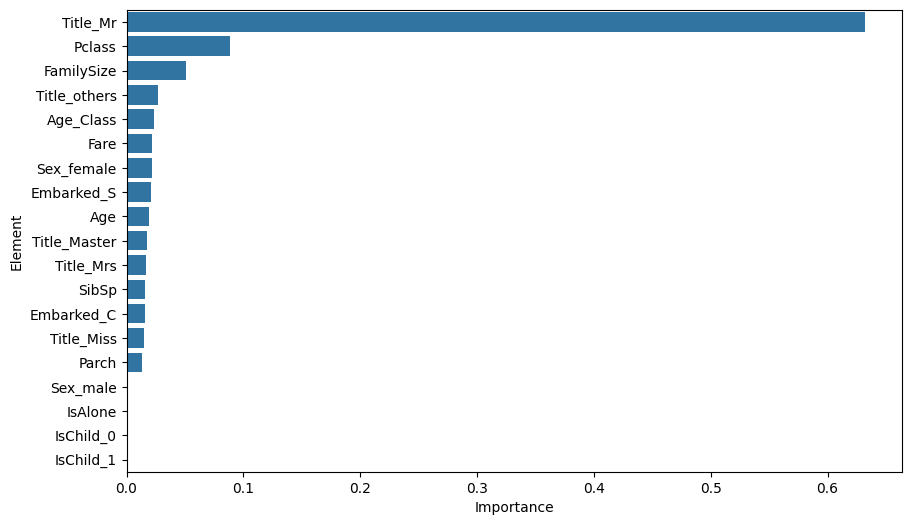

In [109]:
# 주요 피처 확인
importances = best_xgb.feature_importances_
feature_imp = pd.DataFrame({'Element': X_train_final.columns, 'Importance': importances})
feature_imp = feature_imp.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x='Importance', y='Element', data=feature_imp)
plt.show()

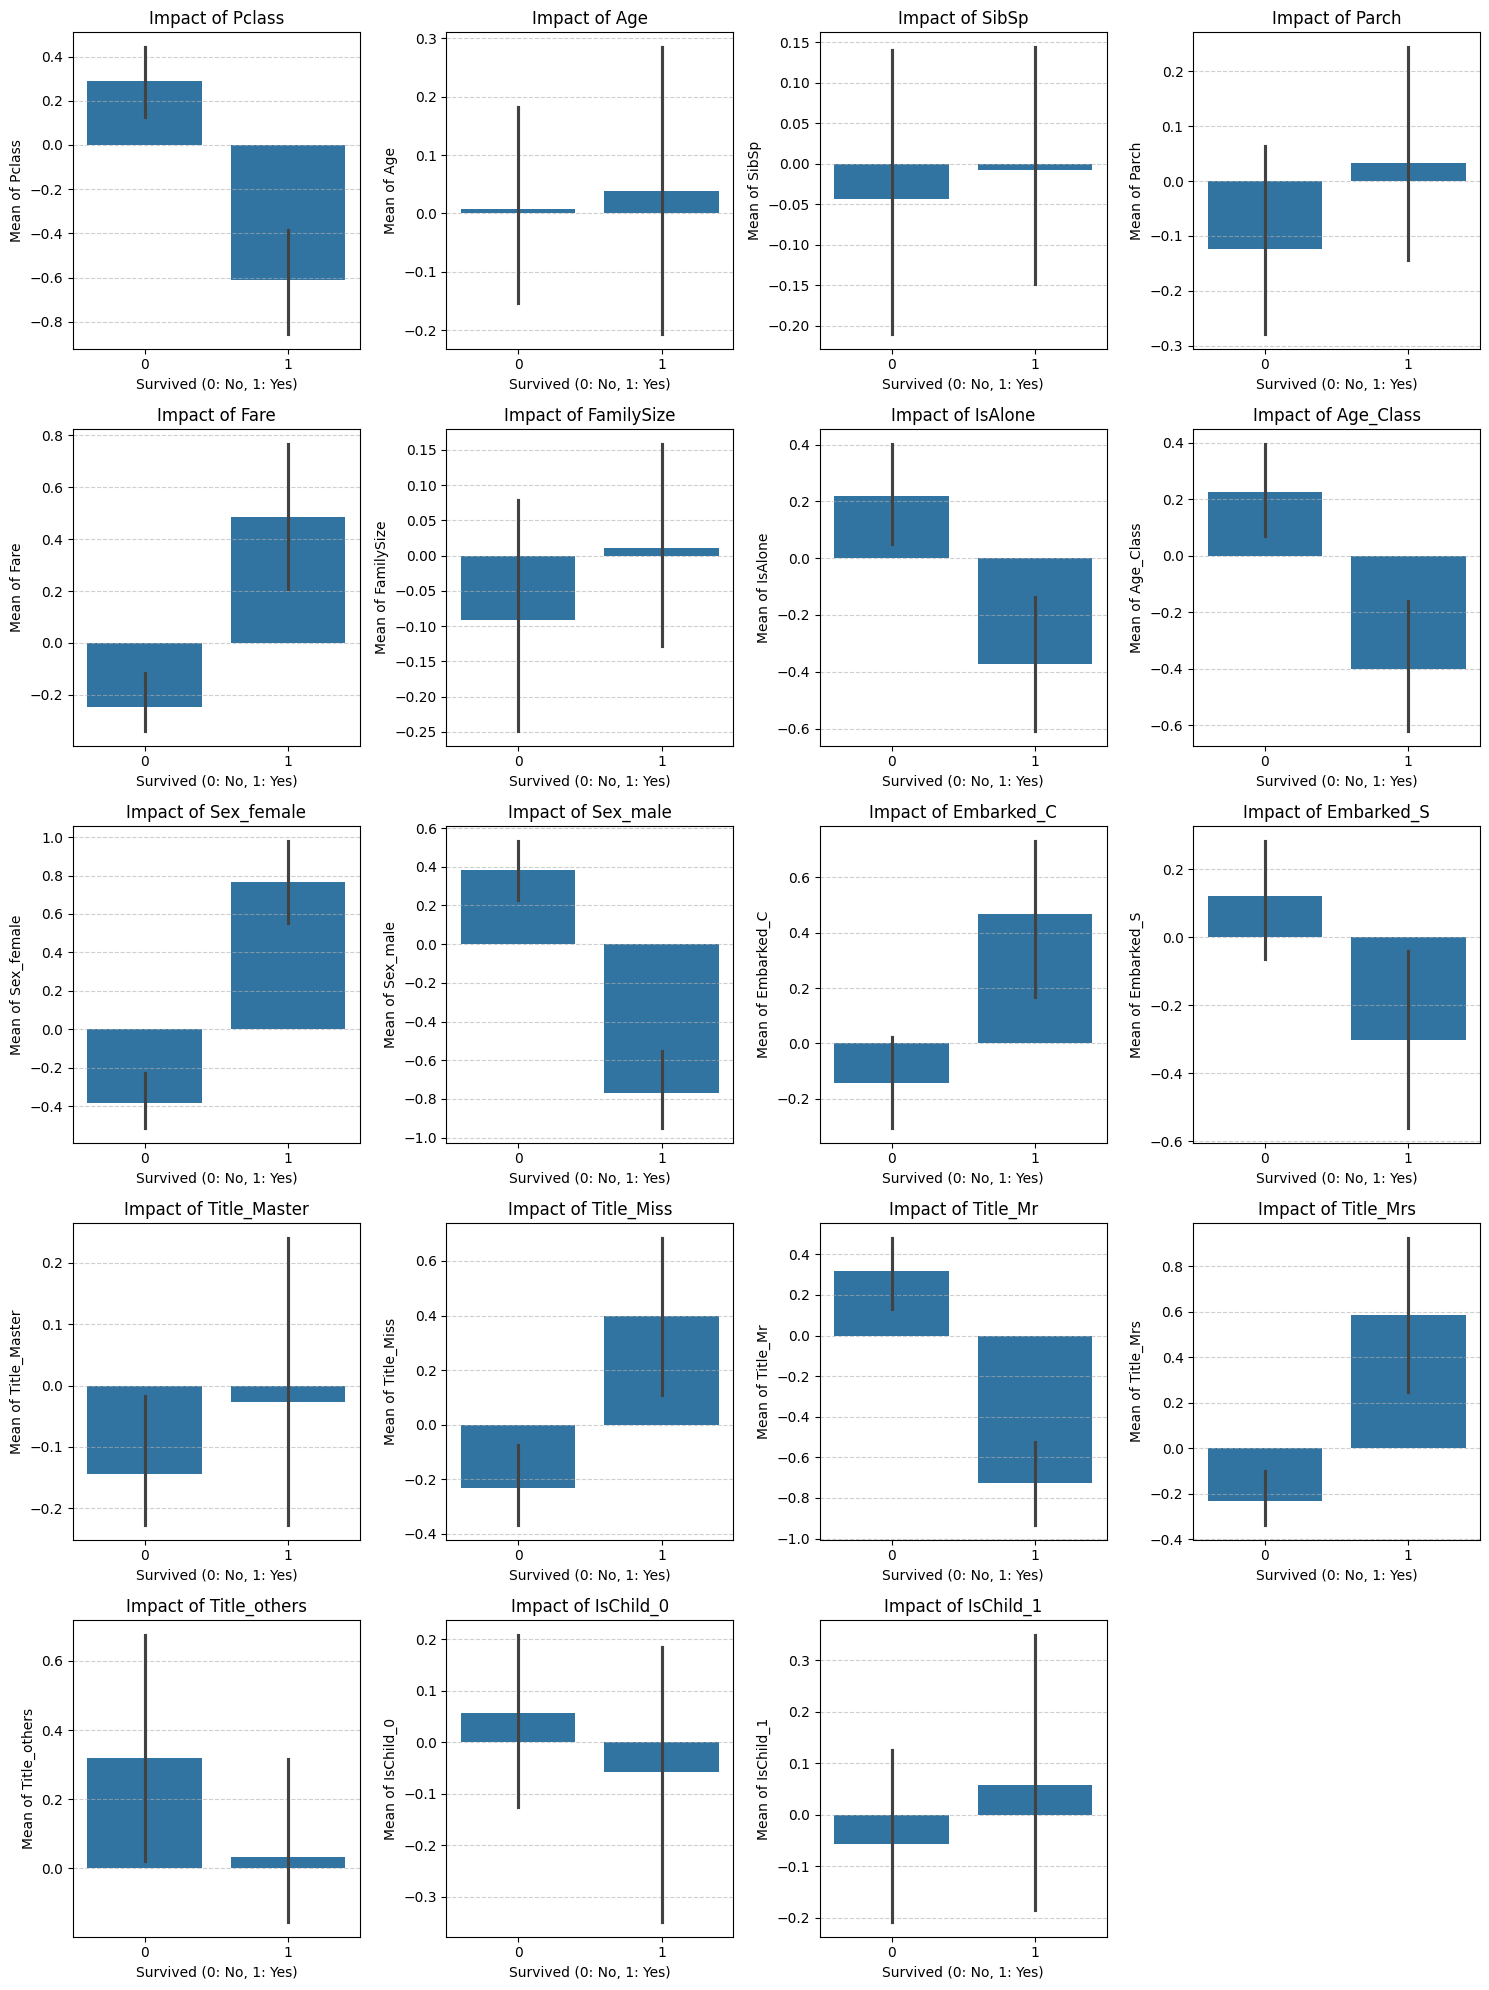

In [110]:
# 피처 조사
X_valid_df = pd.DataFrame(X_val_final, columns=X_train_final.columns)

suspects = X_train_final.columns

plt.figure(figsize=(15, 20))

for i, element in enumerate(suspects):
    plt.subplot(5, 4, i+1)
    sns.barplot(x=y_val_final, y=X_valid_df[element])    
    plt.title(f"Impact of {element}")
    plt.xlabel("Survived (0: No, 1: Yes)")
    plt.ylabel(f"Mean of {element}")
    plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

In [111]:
# 성인 남성(Mr, male) -> 생존률 낮음
# 여성(Miss, female) -> 생존률 높음
# 돈(Fare): 높은 요금을 낸 그룹이 생존률 더 높음
# 계급(Pclass): 고위층일수록 생존률 높음
# 나이, 자녀, 배우자 유무는 생존률에 큰 영향 없음

# 피처 조합하여 다시 모델링
# -> 혼자보다 가족이 있는 경우 생존률이 더 높음

In [112]:
# 테스트 데이터 기본 전처리 및 결측치 채우기
test['Title'] = test['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)
test['Title'] = test['Title'].apply(lambda x: x if x in target_title else 'others')

test['Age'] = test['Age'].fillna(test['Title'].map(title_age_map))
test['Age'] = test['Age'].fillna(train_dropped3['Age'].median())
test['Fare'] = test['Fare'].fillna(train_dropped3['Fare'].median())

# 피처 추가 (IsChild 포함)
test['FamilySize'] = test['SibSp'] + test['Parch'] + 1
test['IsAlone'] = (test['FamilySize'] == 1).astype(int)
test['FareBin'] = pd.qcut(test['Fare'], 4, labels=[0, 1, 2, 3]).astype(int) # 인코딩 전이라 유지
test['Age_Class'] = test['Age'] * test['Pclass']
test['IsChild'] = (test['Age'] < 16).astype(int)

# 인코딩 및 합치기
test_dropped = test.drop(columns=['PassengerId', 'Name', 'Ticket', 'Cabin'])
encoded_test = ohencoder.transform(test_dropped[cols_to_encode])
oh_cols_test = pd.DataFrame(encoded_test, columns=encoded_columns_names, index=test_dropped.index)

num_X_test = test_dropped.drop(cols_to_encode, axis=1)
oh_X_test = pd.concat([num_X_test, oh_cols_test], axis=1)

# 스케일링 (훈련 데이터 기준 scaler 사용)
scaled_X_test = pd.DataFrame(scaler.transform(oh_X_test), columns=oh_X_test.columns)

# 노이즈 제거 (훈련 데이터와 동일한 컬럼 삭제)
X_test_final = scaled_X_test.drop(columns=drop_cols, errors='ignore')

<>:2: SyntaxWarning: invalid escape sequence '\.'
<>:2: SyntaxWarning: invalid escape sequence '\.'
/tmp/ipykernel_55/758119170.py:2: SyntaxWarning: invalid escape sequence '\.'
  test['Title'] = test['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)


In [113]:
from sklearn.ensemble import VotingClassifier, RandomForestClassifier

# XGBoost
xgb_best = XGBClassifier(gamma=0.04, learning_rate=0.05, max_depth=5, n_estimators=106, subsample=1.0)

# RandomFores
rf_best = RandomForestClassifier(n_estimators=96, max_depth=5, min_samples_leaf=1, min_samples_split=3, random_state=0)

# 소프트 보팅 앙상블
final_voting_model = VotingClassifier(
    estimators=[('xgb', xgb_best), ('rf', rf_best)],
    voting='soft'
)

# 학습 및 예측
final_voting_model.fit(X_train_final, y_train_final)
final_predictions = final_voting_model.predict(X_test_final)

In [114]:
# 제출 파일 양식에 맞게 데이터프레임 생성
submission = pd.DataFrame({
    "PassengerId": test_passenger_id,
    "Survived": final_predictions
})

# CSV 파일로 저장
submission.to_csv('titanic_submission_v4.csv', index=False)
print("제출 파일 준비됨")

제출 파일 준비됨
